Columns found: ['step', 'time', 'ResidMax', 'ResidRMS', 'DilMax', 'IntDiv', 'IntAbsDiv', 'dt']
Loaded 2 time steps


/tmp/ipykernel_79671/979304208.py:97: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


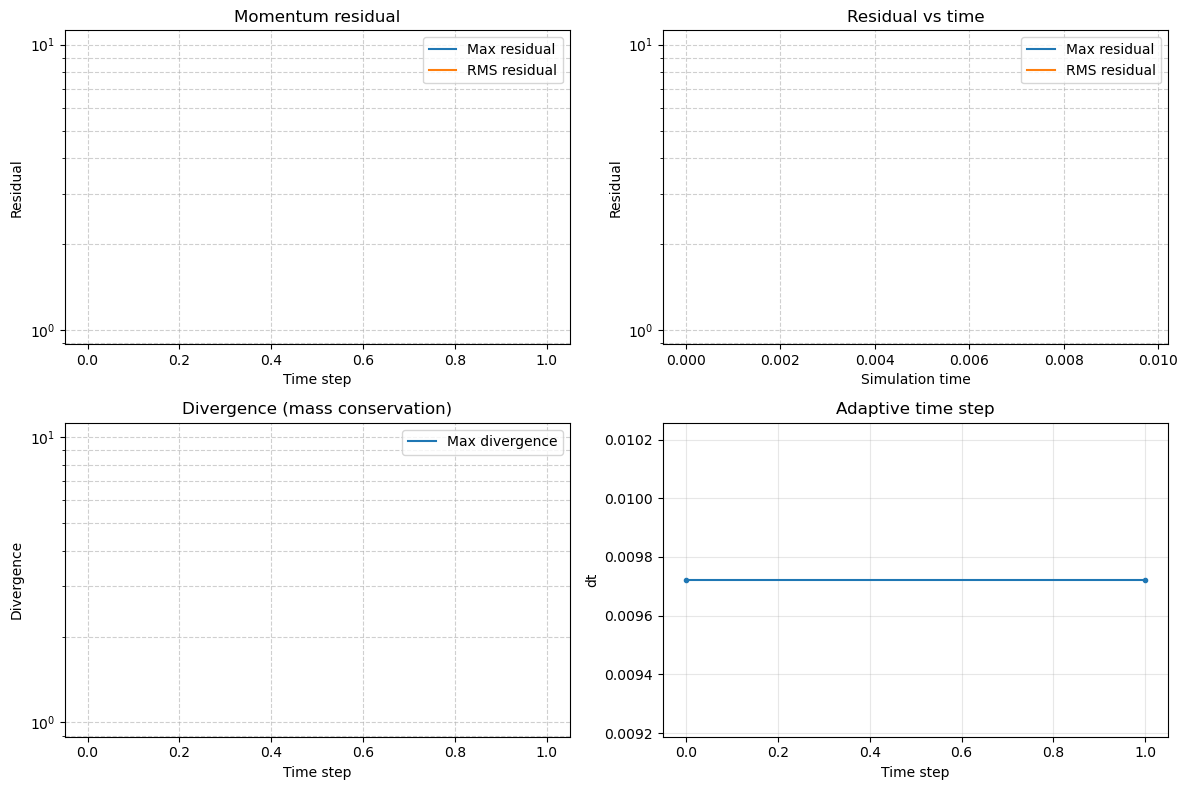


--- Final values ---
Step            : 1.0
Time            : 0.009722
ResidMax        : 0.000e+00
ResidRMS        : 0.000e+00
DilMax          : 0.000e+00


In [ ]:
# %% [markdown]
# # NavSolver Convergence Plotter
# 
# Reads the `*_convergence.csv` file generated by the solver and plots:
# - Momentum residual (max & RMS) vs. time step / simulation time
# - Divergence (max & integrated absolute) vs. time
# - Time step evolution (if present)
# 
# Adjust the file name below.

# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Load the data
# ------------------------------
csv_file = "../../results/backstep/step_re100_convergence.csv"  # <-- change to your file
df = pd.read_csv(csv_file)

# Check available columns
print("Columns found:", list(df.columns))
print(f"Loaded {len(df)} time steps")

# If no 'time' column, create one from step index or dt accumulation
if 'time' not in df.columns and 'step' in df.columns:
    # approximate time as cumulative dt (if dt column exists)
    if 'dt' in df.columns:
        df['time'] = df['dt'].cumsum()
    else:
        df['time'] = df['step']  # fallback: step number

# Rename columns for convenience (if needed)
df.rename(columns={
    'ResidMax': 'resid_max',
    'ResidRMS': 'resid_rms',
    'DilMax':   'dil_max',
    'IntAbsDil': 'int_abs_dil',
    'IntDil':    'int_dil'
}, inplace=True, errors='ignore')

# %%
# ------------------------------
# 2. Plot residuals
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals vs step number
ax = axes[0,0]
if 'resid_max' in df.columns:
    ax.semilogy(df['step'], df['resid_max'], label='Max residual')
if 'resid_rms' in df.columns:
    ax.semilogy(df['step'], df['resid_rms'], label='RMS residual')
ax.set_xlabel('Time step')
ax.set_ylabel('Residual')
ax.set_title('Momentum residual')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()

# Residuals vs simulation time
ax = axes[0,1]
if 'resid_max' in df.columns:
    ax.semilogy(df['time'], df['resid_max'], label='Max residual')
if 'resid_rms' in df.columns:
    ax.semilogy(df['time'], df['resid_rms'], label='RMS residual')
ax.set_xlabel('Simulation time')
ax.set_ylabel('Residual')
ax.set_title('Residual vs time')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()

# Divergence metrics
ax = axes[1,0]
if 'dil_max' in df.columns:
    ax.semilogy(df['step'], df['dil_max'], label='Max divergence')
if 'int_abs_dil' in df.columns:
    ax.semilogy(df['step'], df['int_abs_dil'], label='Integrated |∇·u|')
ax.set_xlabel('Time step')
ax.set_ylabel('Divergence')
ax.set_title('Divergence (mass conservation)')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()

# Time step evolution (if available)
ax = axes[1,1]
if 'dt' in df.columns:
    ax.plot(df['step'], df['dt'], 'o-', markersize=3)
    ax.set_xlabel('Time step')
    ax.set_ylabel('dt')
    ax.set_title('Adaptive time step')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No "dt" column found', ha='center', va='center')
    ax.set_title('Time step not available')

plt.tight_layout()
plt.savefig('convergence_plots.png', dpi=150)
plt.show()

# %% [markdown]
# ### 3. (Optional) Print final values
# %%
if len(df) > 0:
    last = df.iloc[-1]
    print("\n--- Final values ---")
    print(f"Step            : {last.get('step', 'N/A')}")
    print(f"Time            : {last.get('time', 'N/A'):.6f}")
    print(f"ResidMax        : {last.get('resid_max', 'N/A'):.3e}")
    print(f"ResidRMS        : {last.get('resid_rms', 'N/A'):.3e}")
    print(f"DilMax          : {last.get('dil_max', 'N/A'):.3e}")